=== Table 1. Baseline Characteristics (N=1,163) ===
            Variable         Category          N (%)
         Age (years)       Mean +- SD   51.0 +- 15.3
                         Median (IQR)     52 (39-62)
Survival time (days)       Mean +- SD 726.2 +- 810.5
                         Median (IQR)  486 (232-876)
                 Sex             Male    677 (58.2%)
                               Female    486 (41.8%)
           Age group           Middle    504 (43.3%)
                                  Old    354 (30.4%)
                                Young    305 (26.2%)
         Tumor grade               G4    651 (56.0%)
                                   G3    264 (22.7%)
                                   G2    248 (21.3%)
        Primary site        Brain_NOS    706 (60.7%)
                             Cerebrum    436 (37.5%)
                       Other_Specific      21 (1.8%)
       Diagnosis era       After_2005    880 (75.7%)
                          Before_2005    283 (2

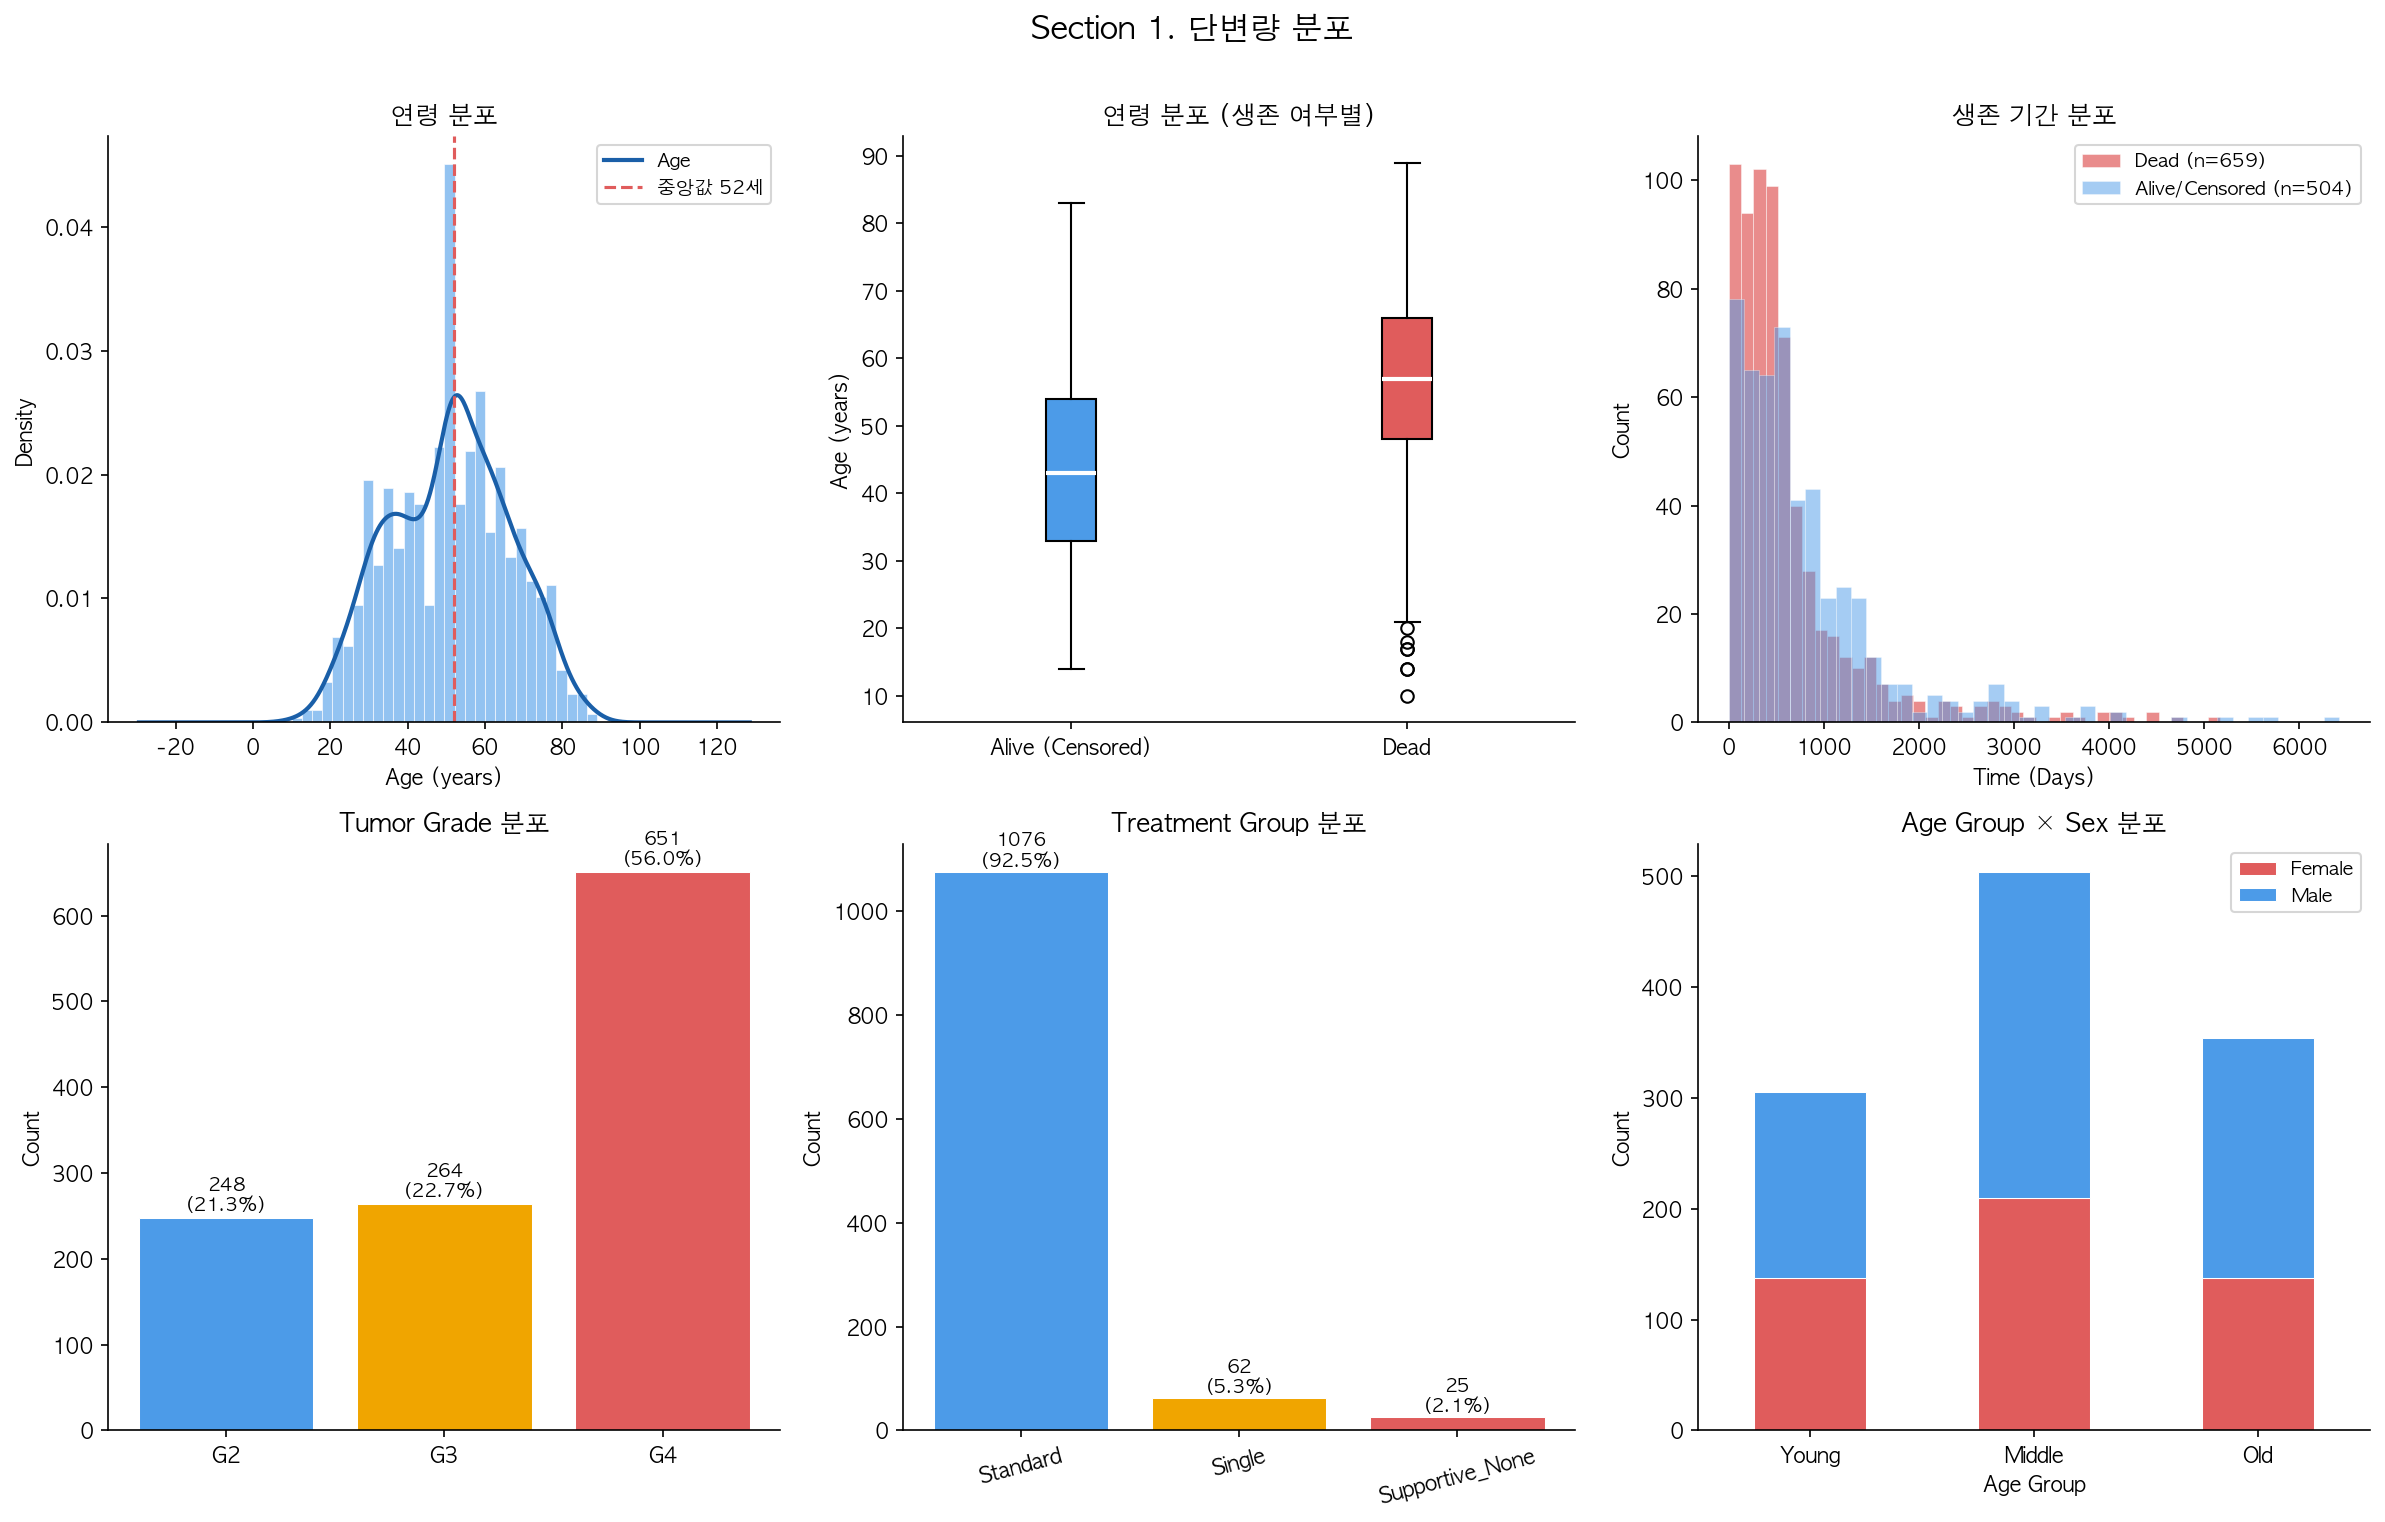

✓ Section 1 완료


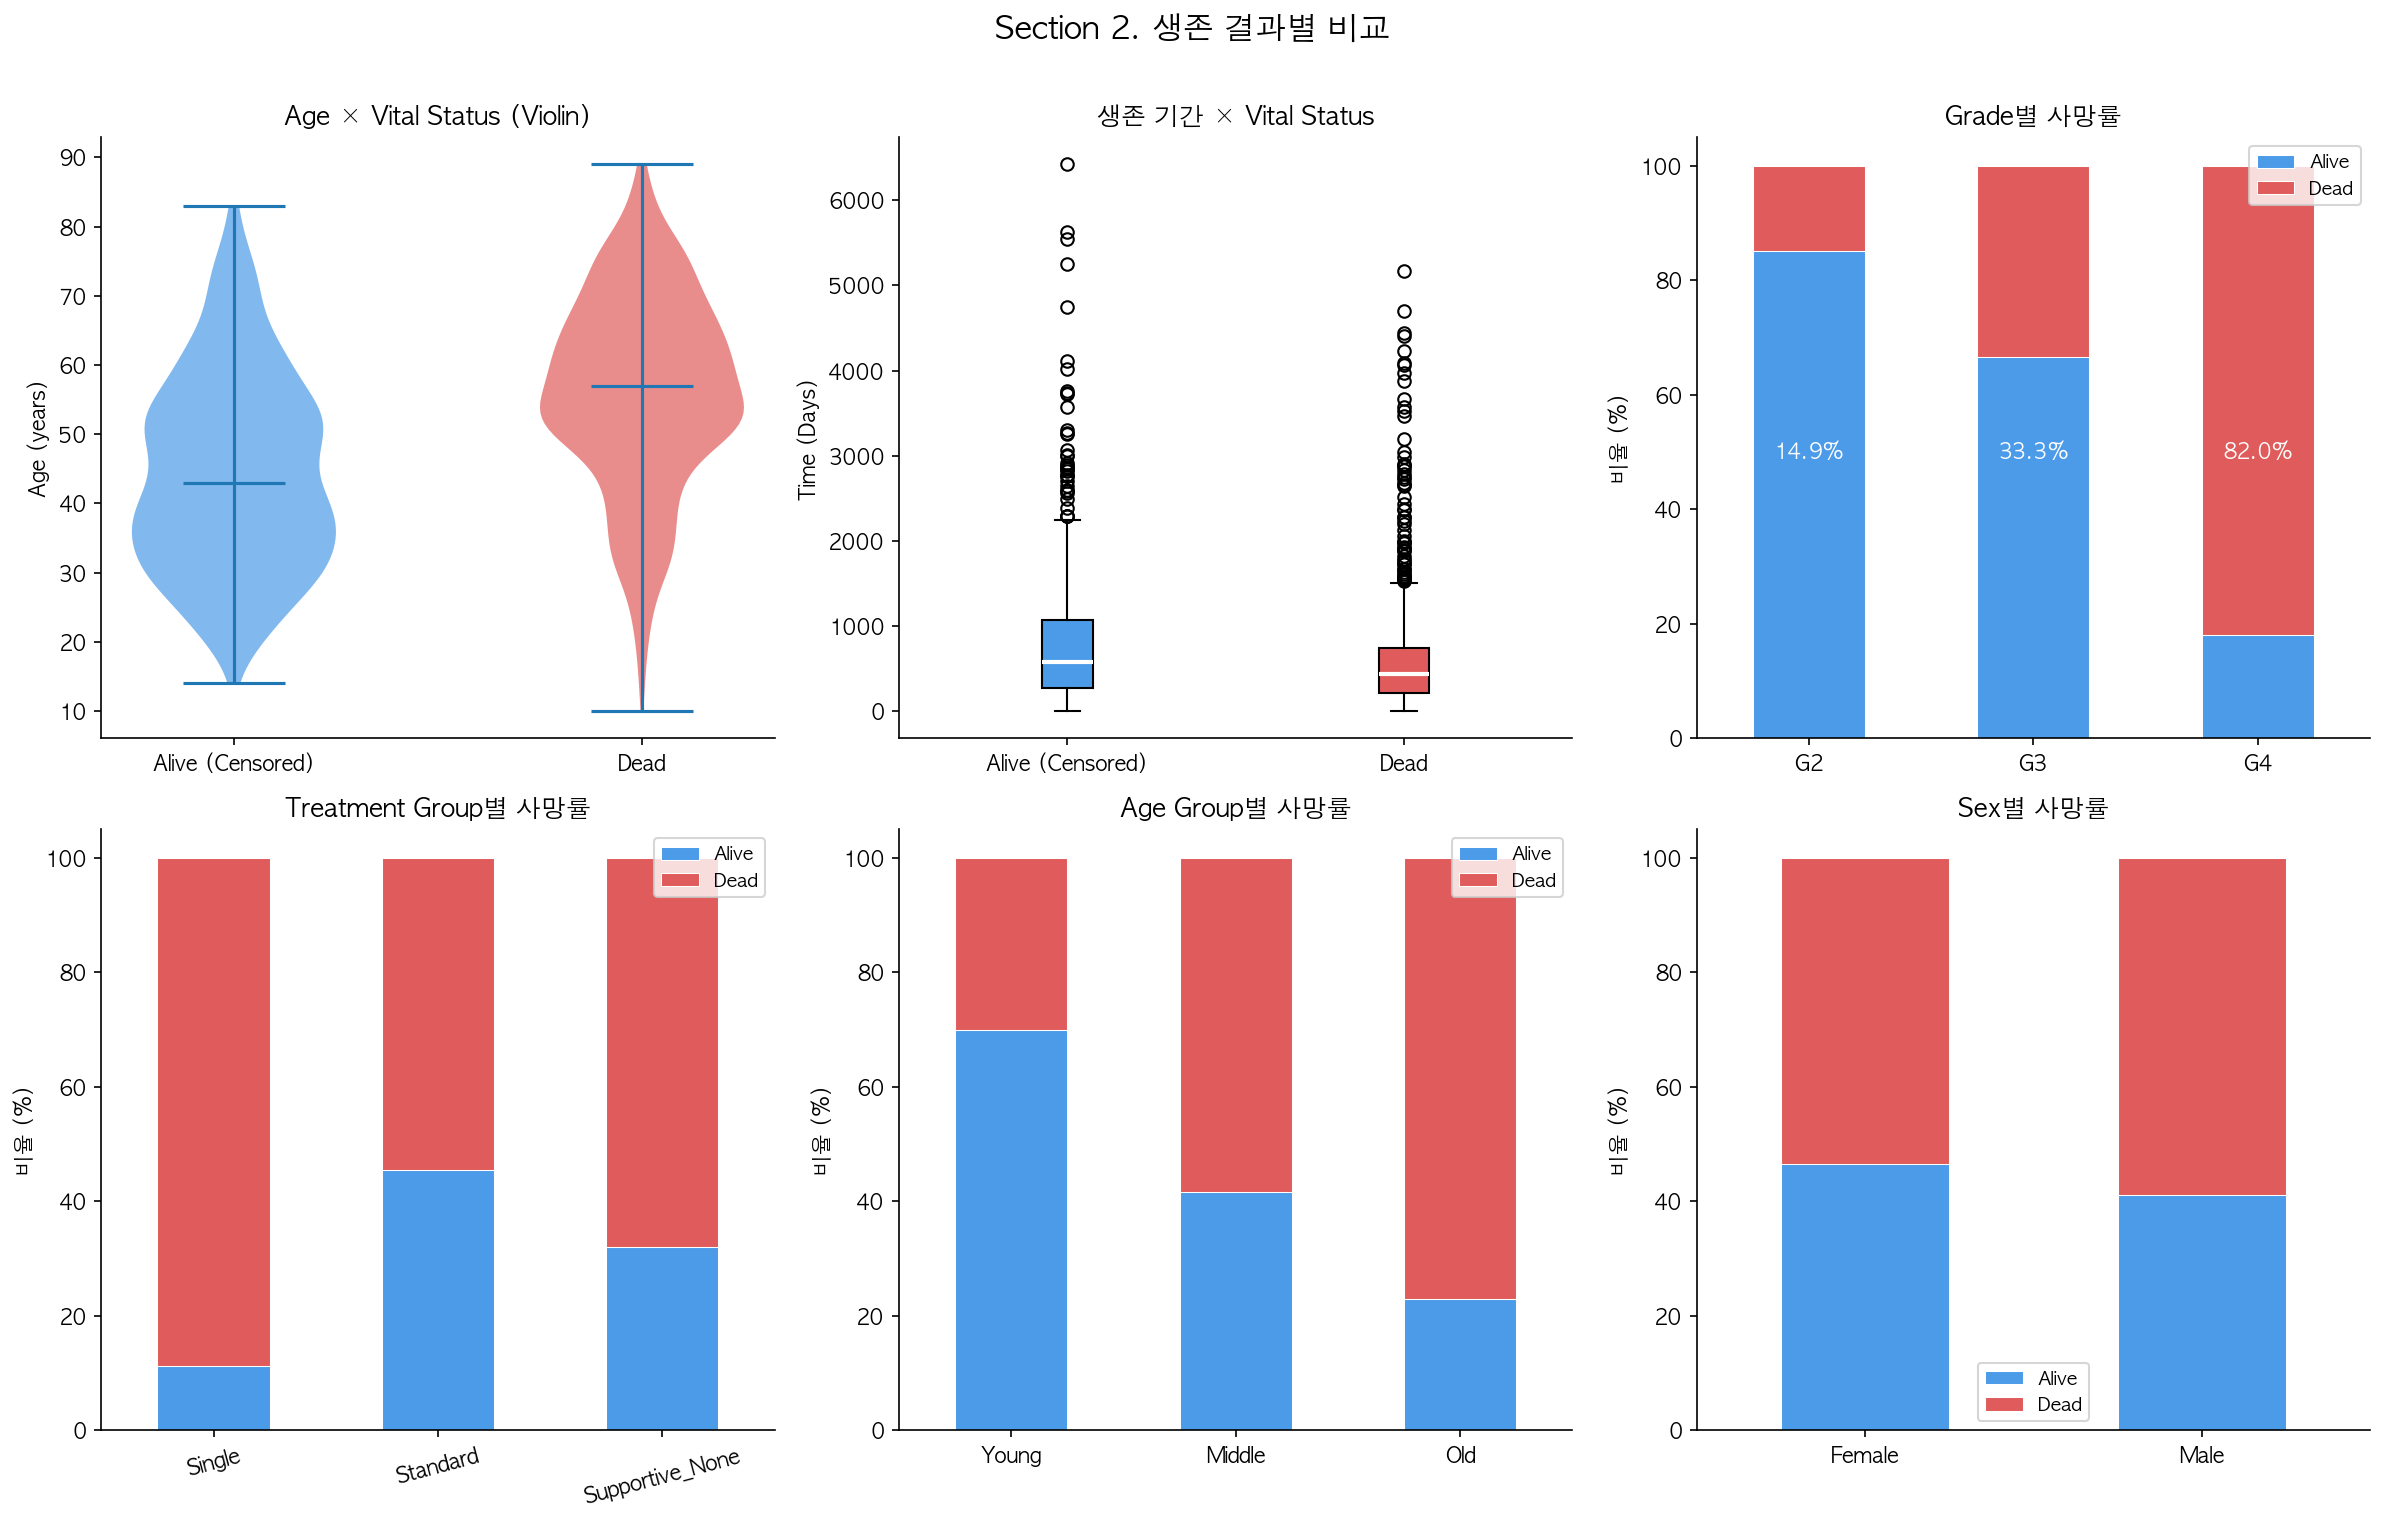

✓ Section 2 완료


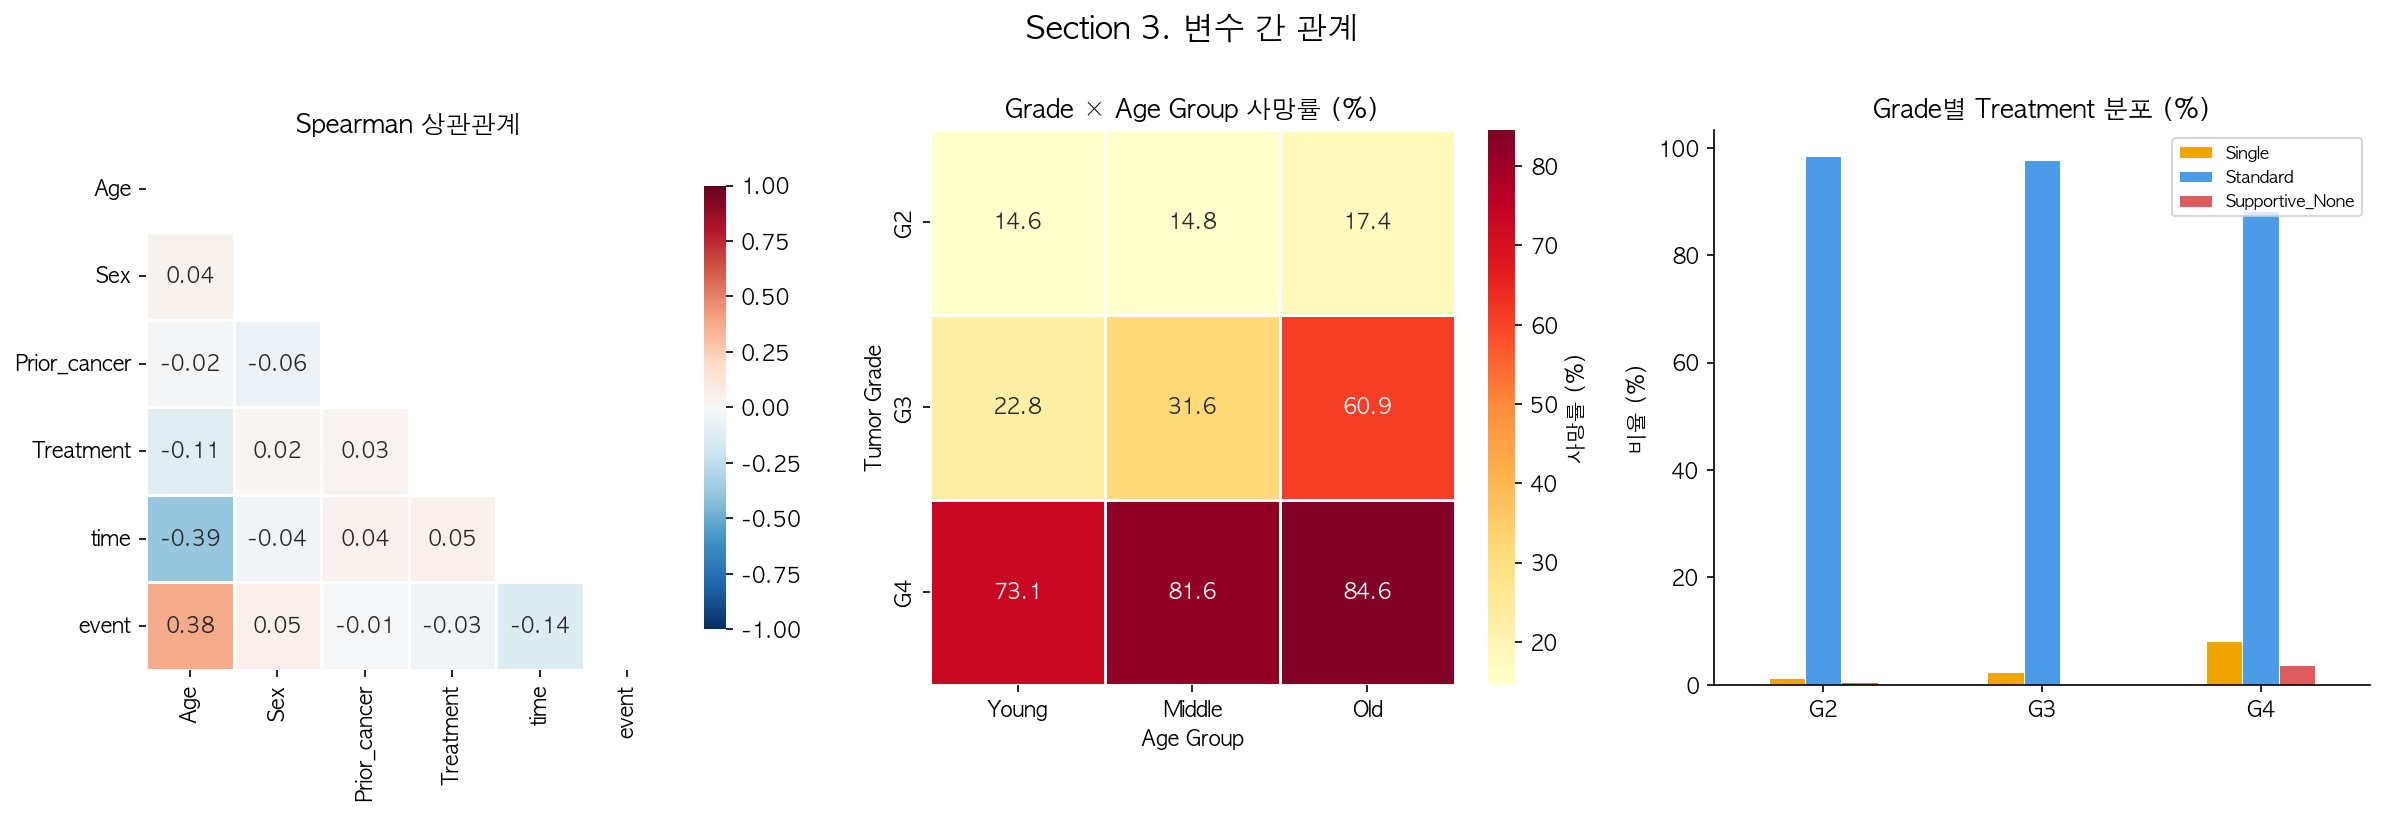

✓ Section 3 완료


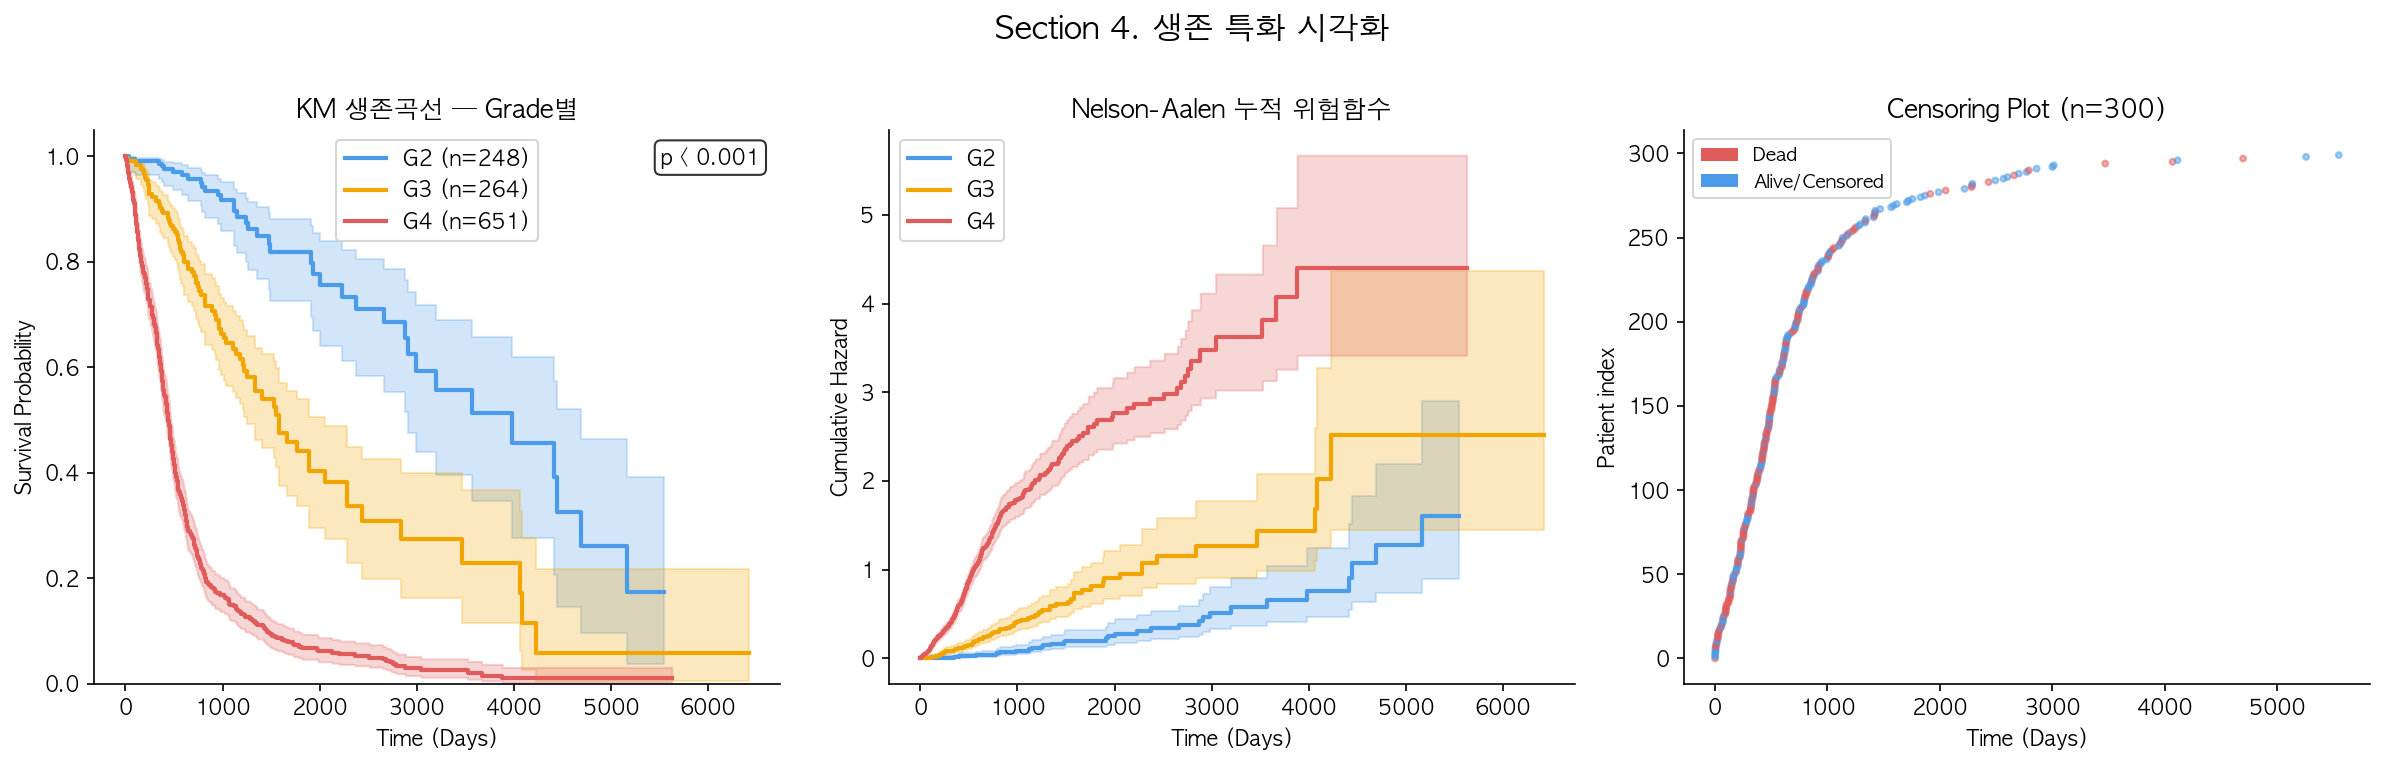

✓ Section 4 완료


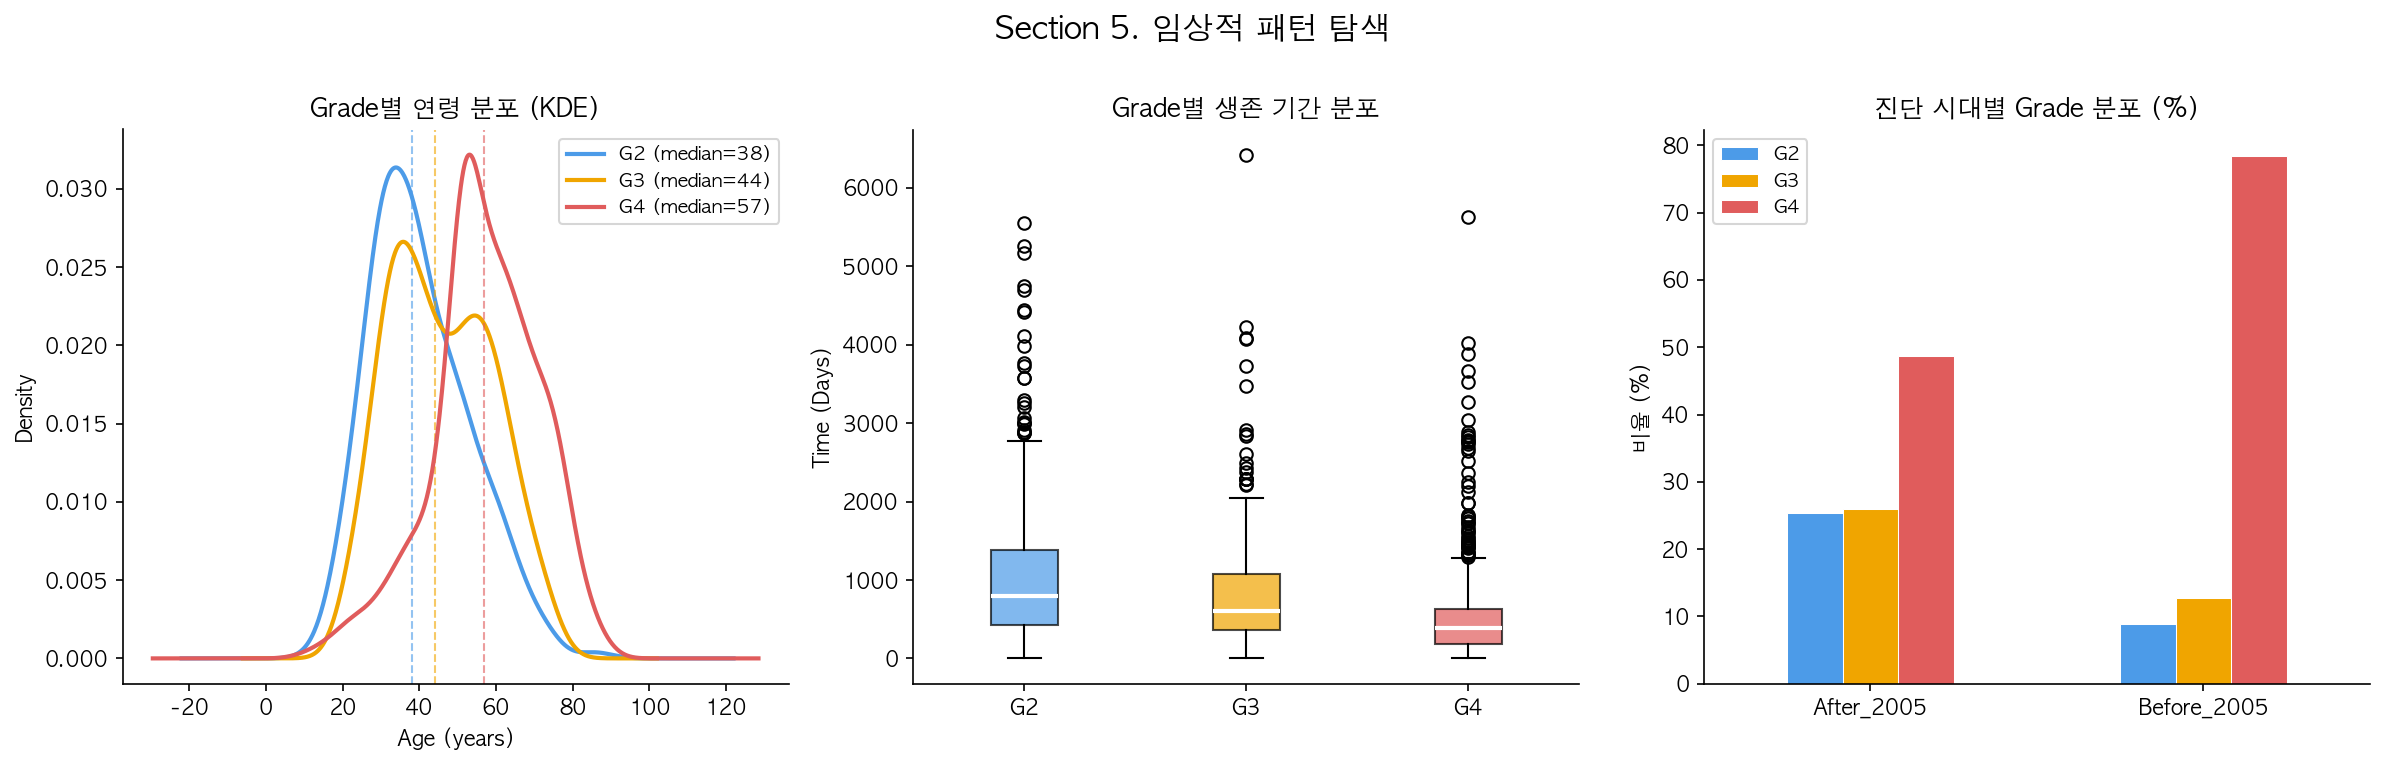

✓ Section 5 완료


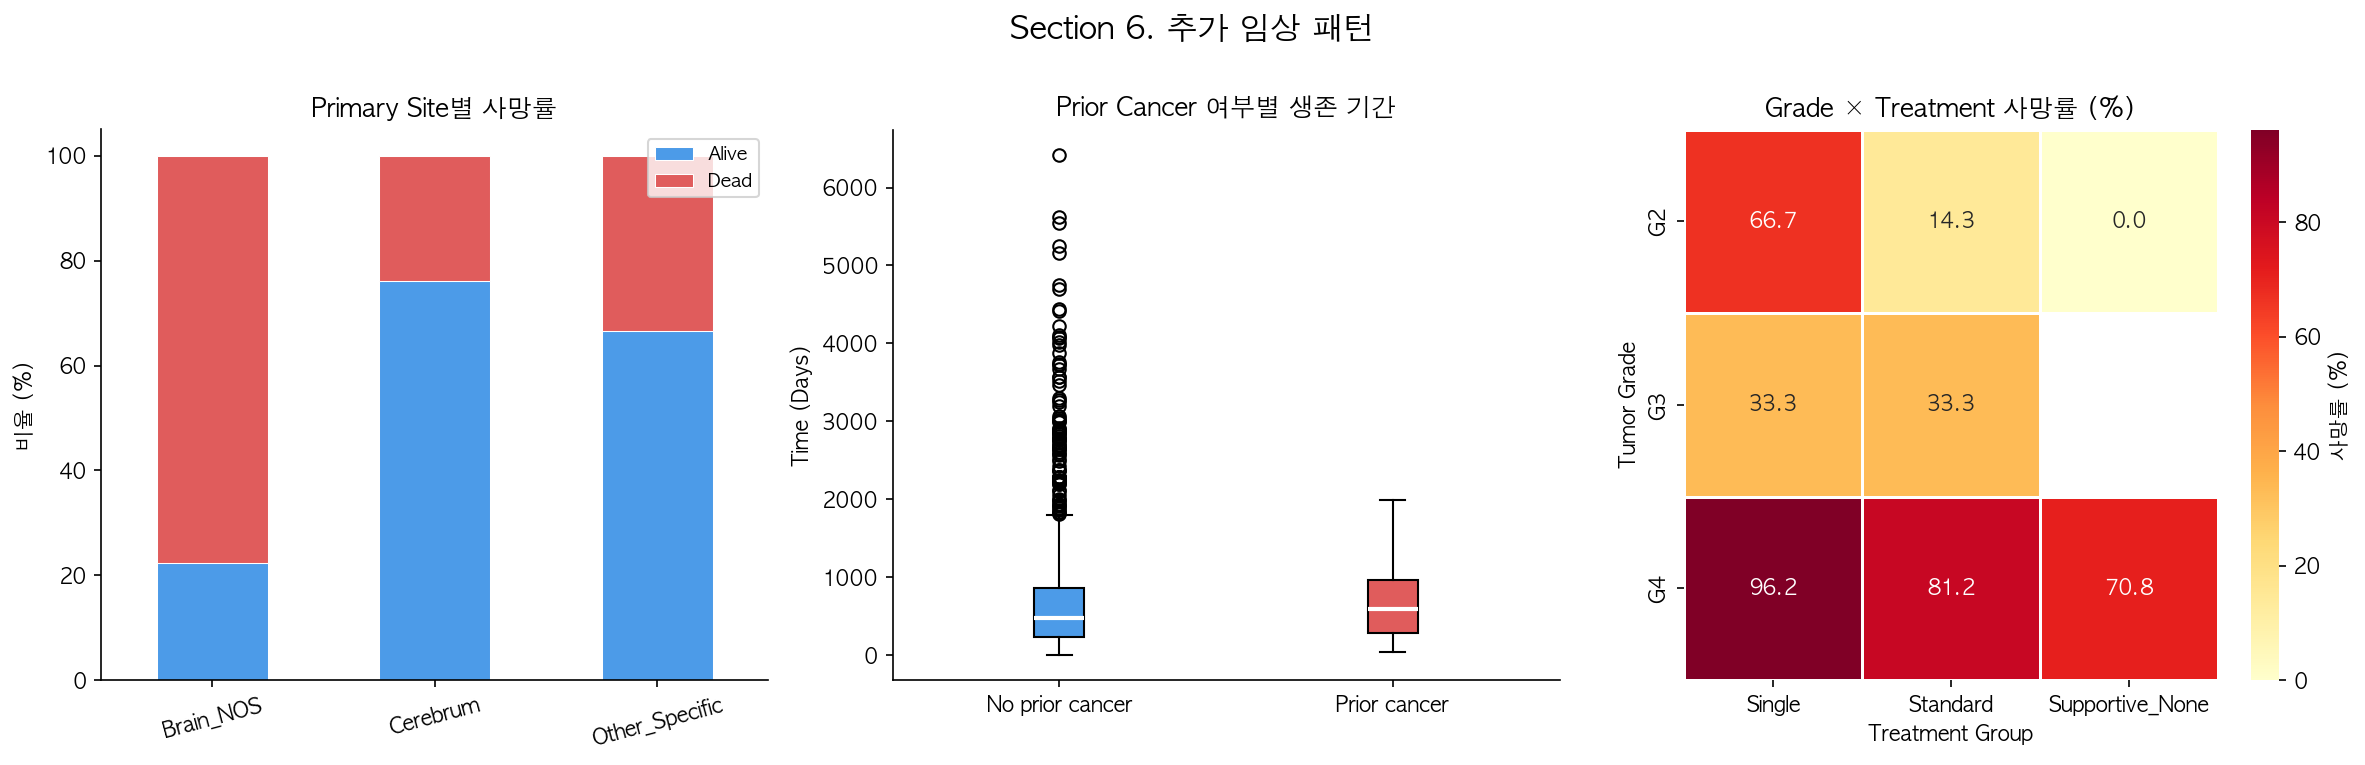

✓ Section 6 완료


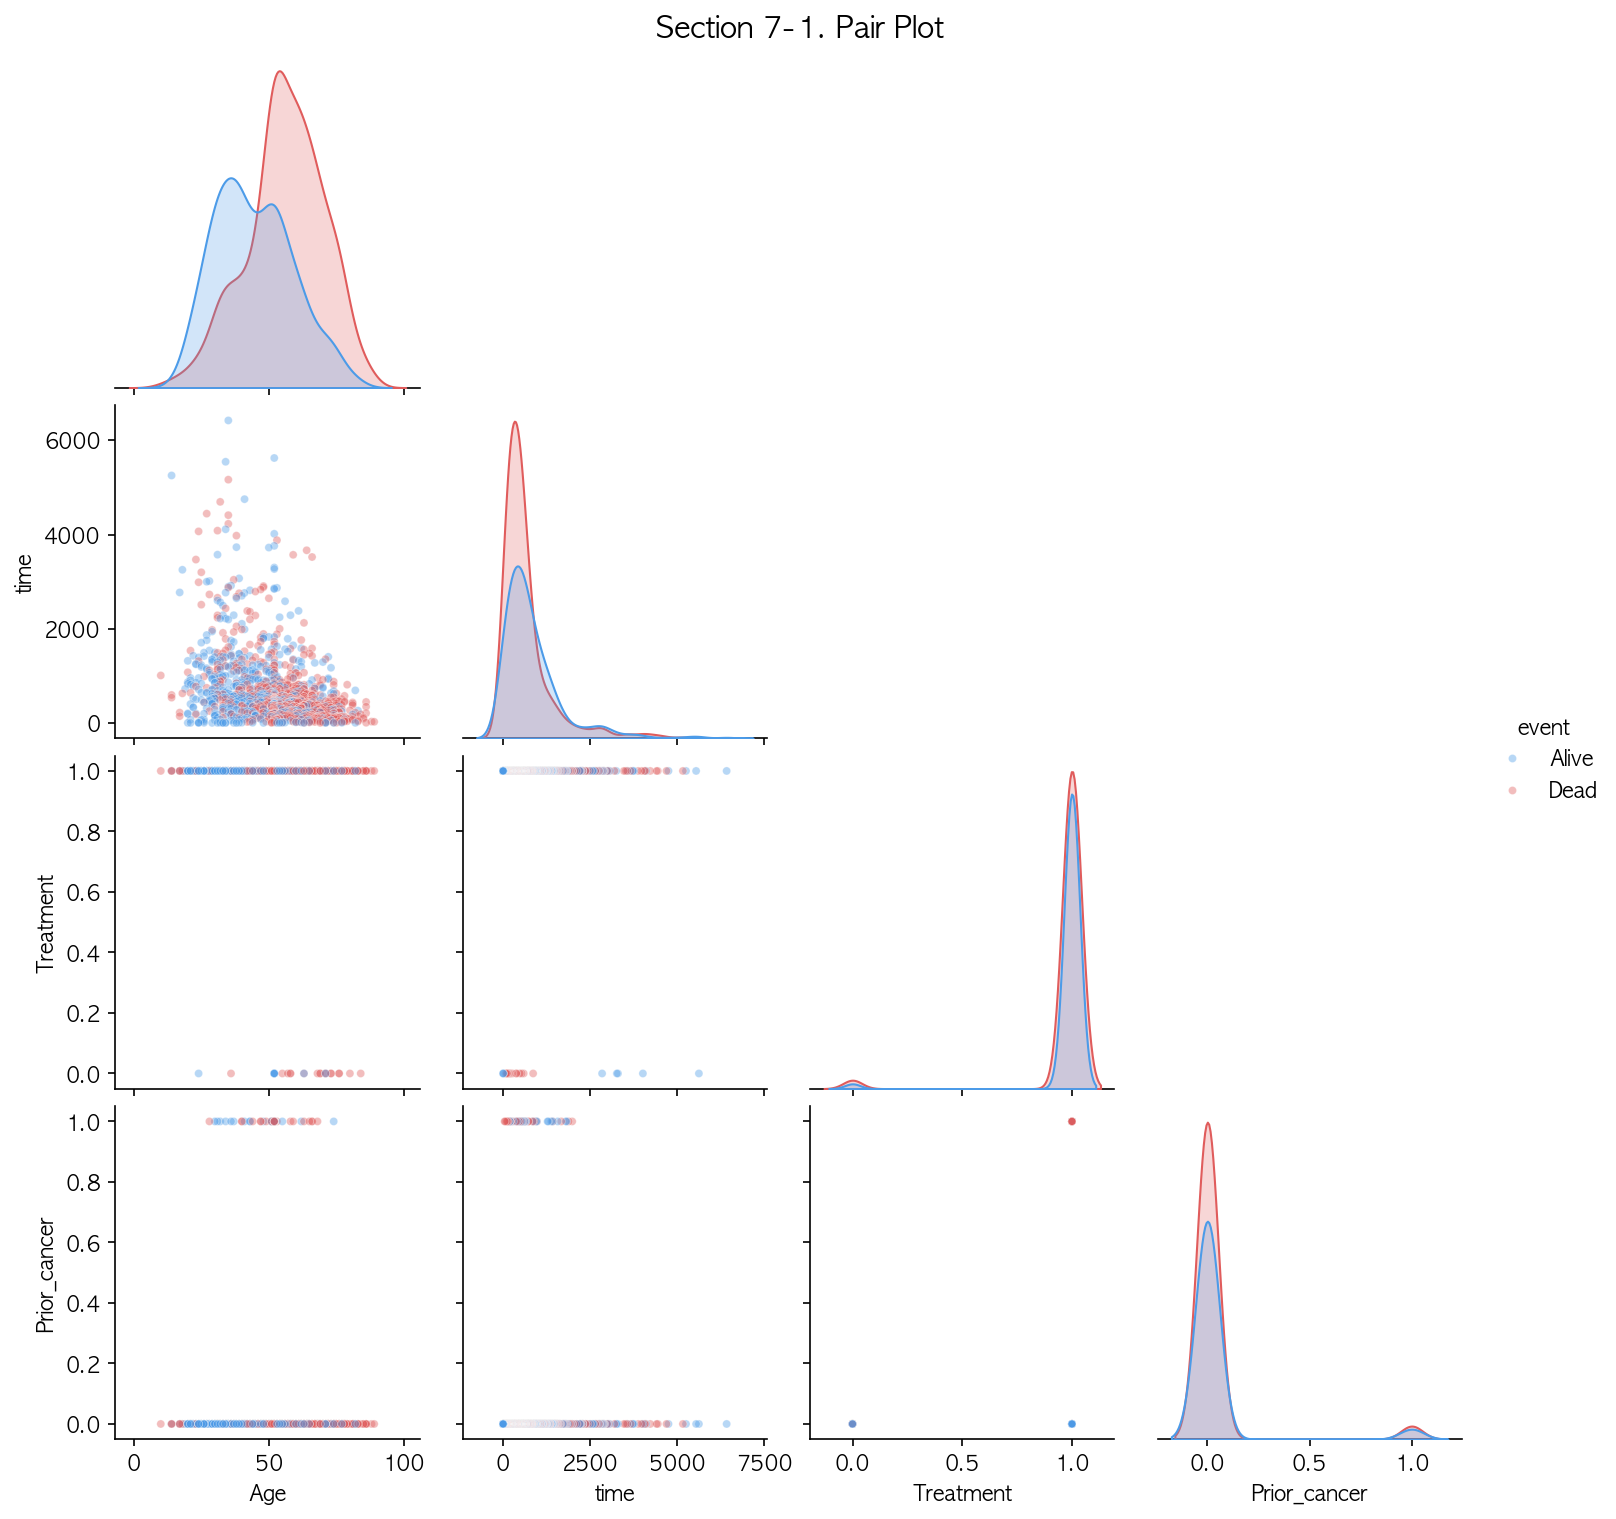

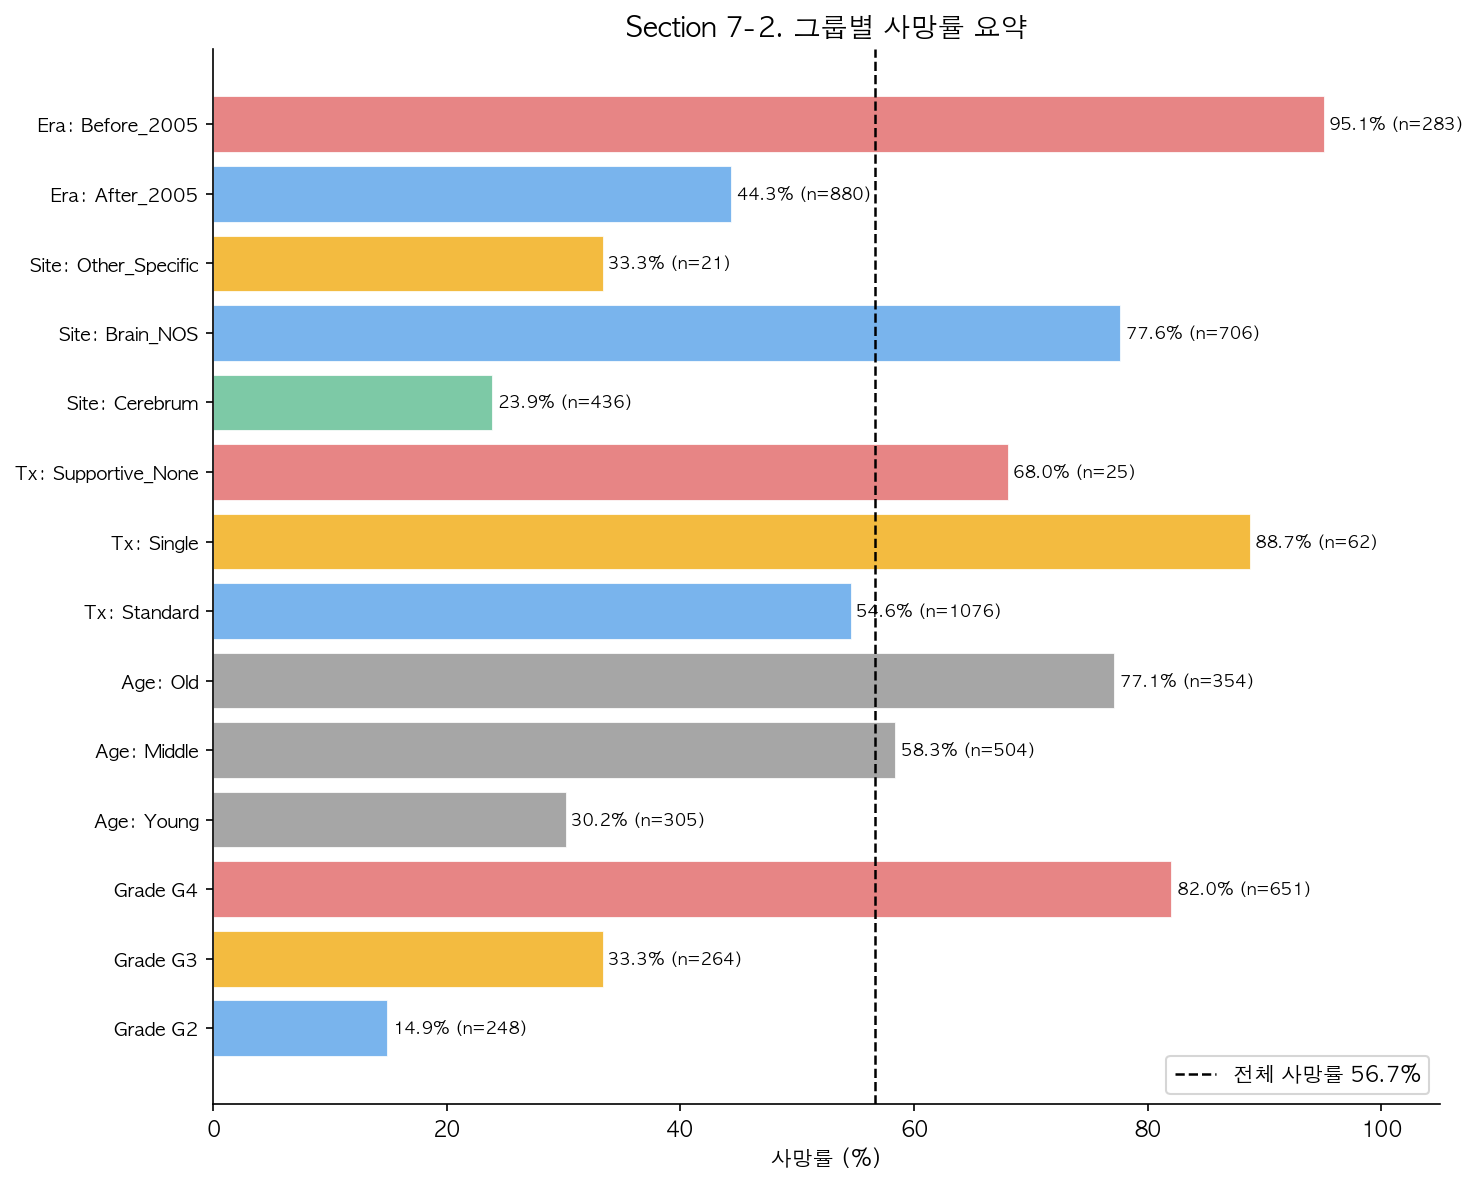

✓ Section 7 완료


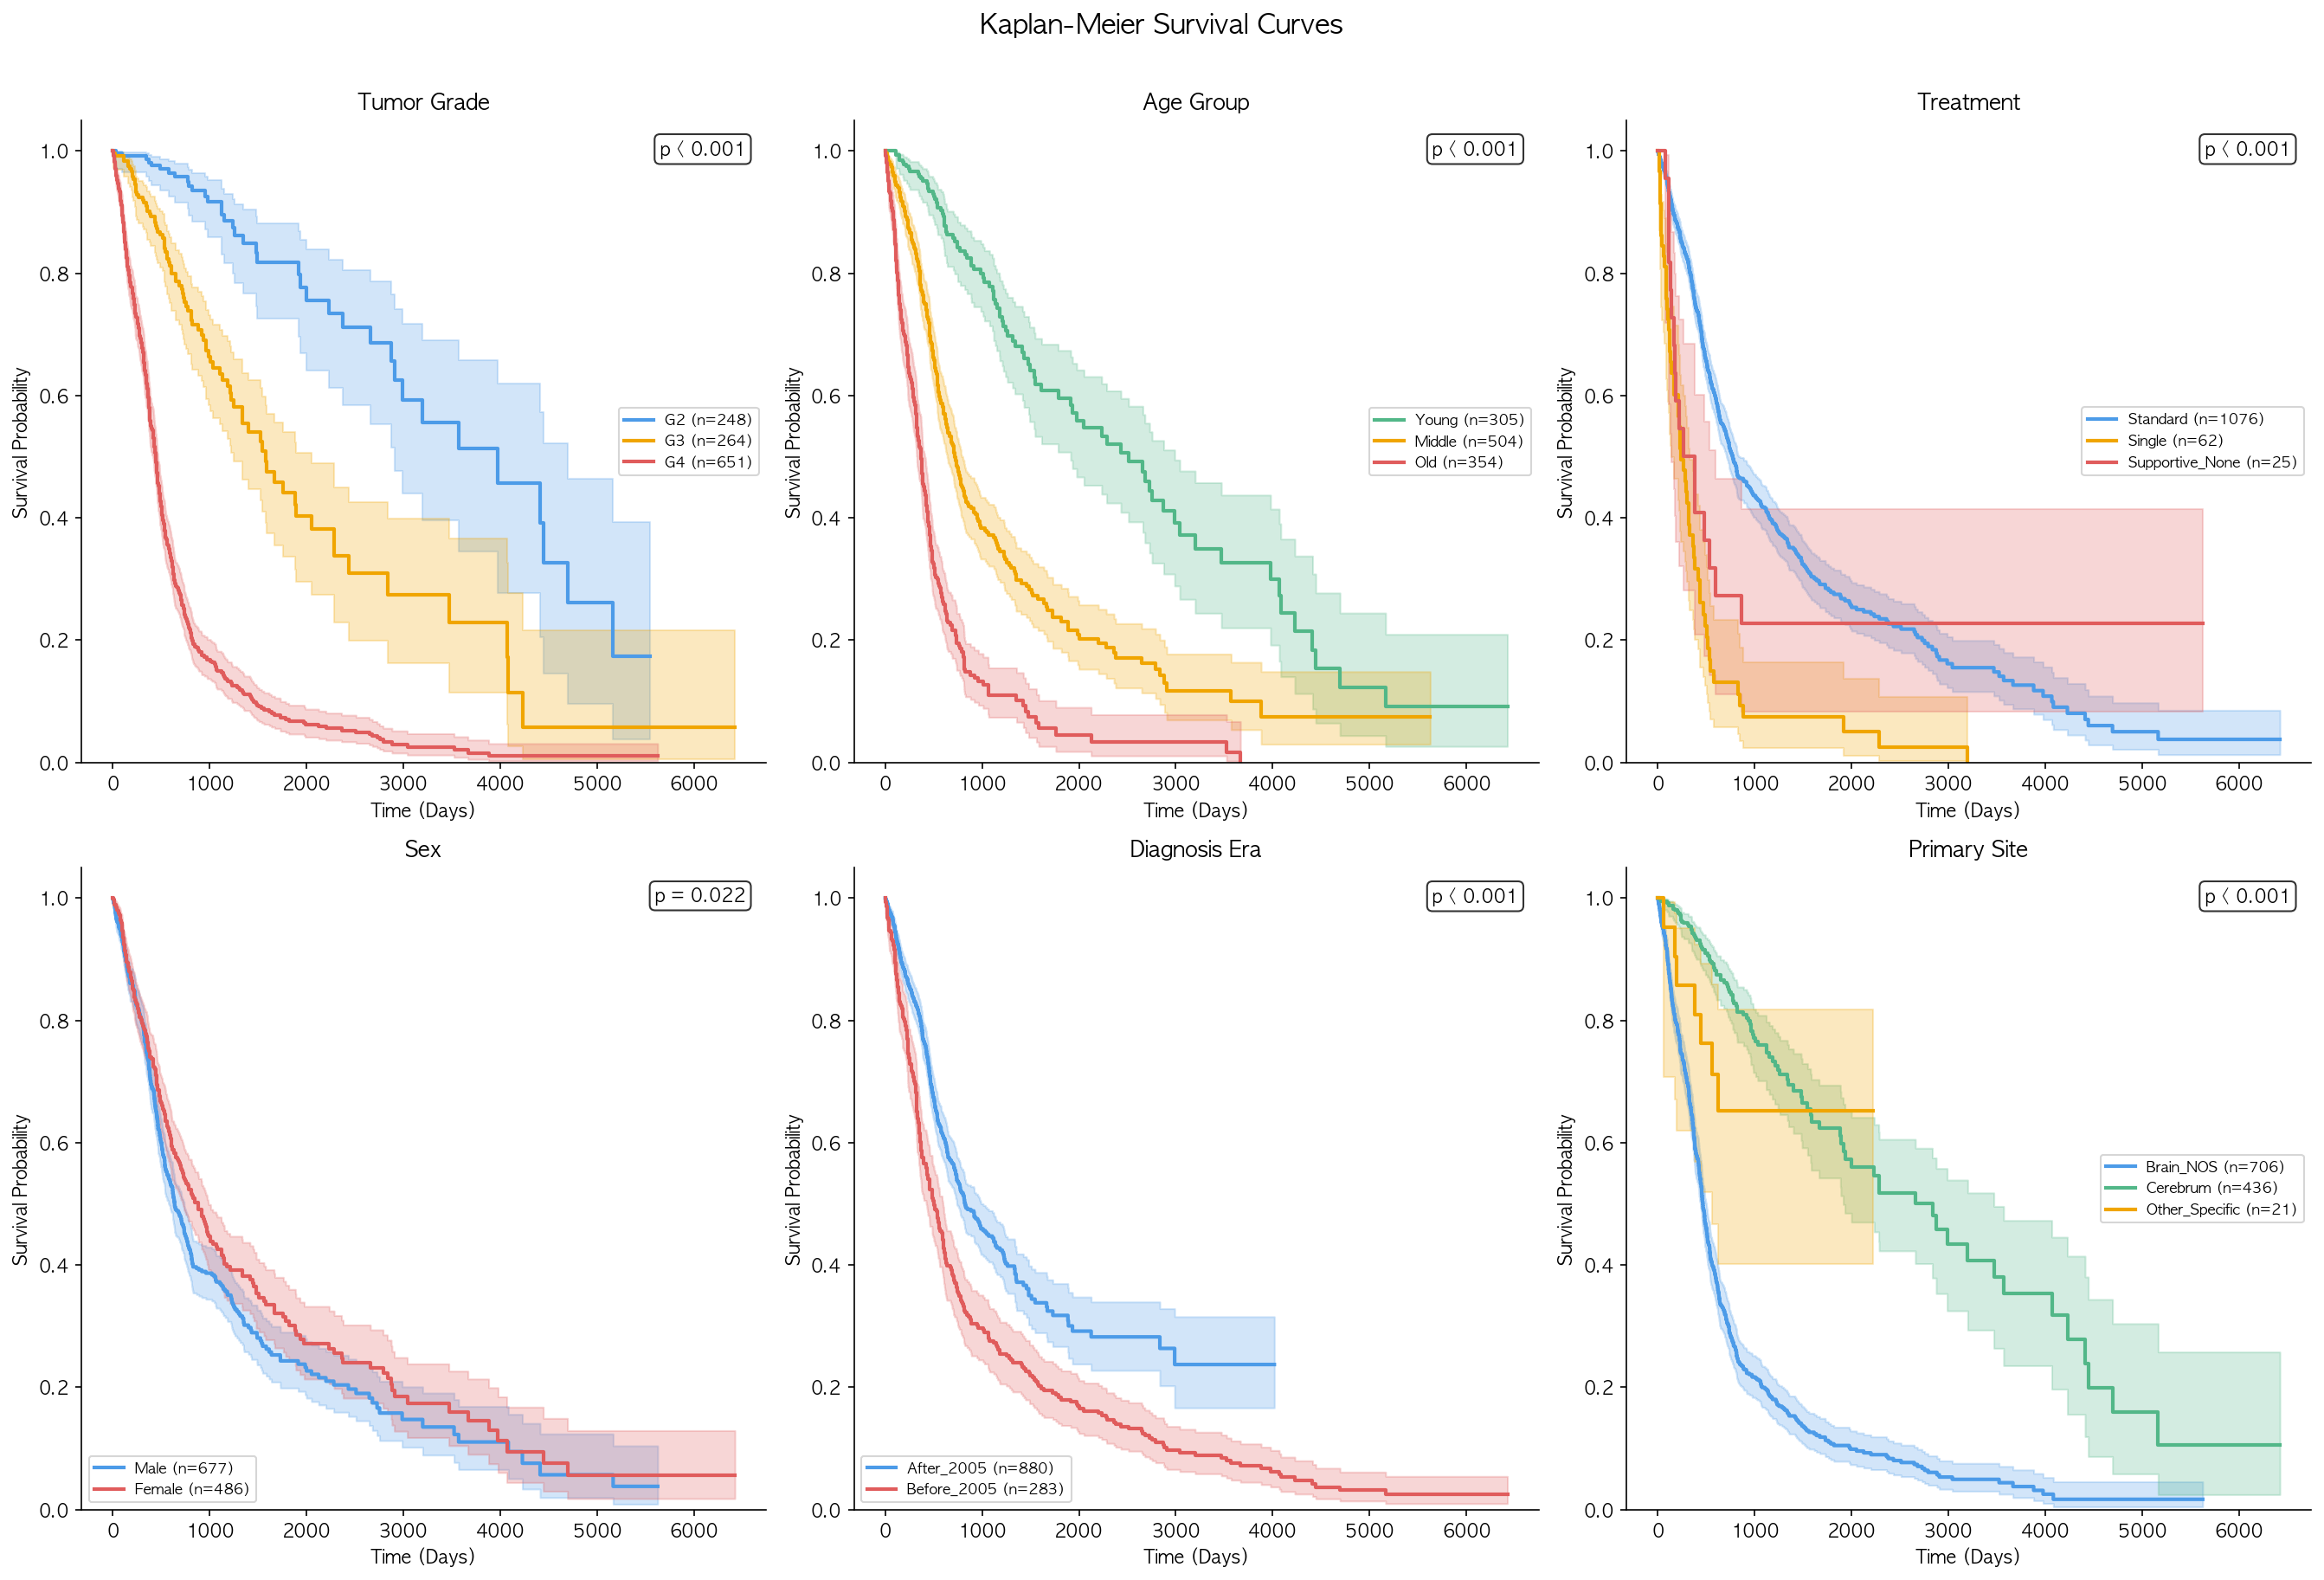


=== 로그순위검정 결과 ===
     Variable  Test stat  p-value Significant
  Tumor Grade    428.439   0.0000         ***
    Age Group    316.821   0.0000         ***
    Treatment     77.411   0.0000         ***
          Sex      5.227   0.0222           *
Diagnosis Era     38.110   0.0000         ***
 Primary Site    294.431   0.0000         ***

=== 그룹별 중앙 생존기간 (Days) ===

[ Tumor Grade ]
  G2                       : 3978일
  G3                       : 1578일
  G4                       : 442일

[ Age Group ]
  Young                    : 2512일
  Middle                   : 715일
  Old                      : 372일

[ Treatment ]
  Standard                 : 772일
  Single                   : 235일
  Supportive_None          : 269일

[ Sex ]
  Male                     : 639일
  Female                   : 880일

[ Diagnosis Era ]
  After_2005               : 821일
  Before_2005              : 503일

[ Primary Site ]
  Brain_NOS                : 466일
  Cerebrum                 : 2835일
  Other_Specific        

In [1]:
# ============================================================
# NB 02. 기초통계량 & EDA — 전체 시각화
# Brain Tumor Survival Analysis — Explainable AI
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import KaplanMeierFitter, NelsonAalenFitter
from lifelines.statistics import multivariate_logrank_test
from matplotlib.patches import Patch
import joblib
import warnings
import os
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family'      : 'AppleGothic',   # Mac: AppleGothic / Windows: Malgun Gothic
    'axes.unicode_minus': False,
    'figure.dpi'       : 150,
    'savefig.dpi'      : 300,
    'savefig.bbox'     : 'tight',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})

OUTPUT_DIR = "./outputs/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

df = joblib.load("./outputs/models/df_survival.pkl")

# 공통 색상 팔레트
GRADE_COLORS = {'G2': '#4C9BE8', 'G3': '#F0A500', 'G4': '#E05C5C'}
EVENT_COLORS = {0: '#4C9BE8', 1: '#E05C5C'}
TX_COLORS    = {
    'Standard'      : '#4C9BE8',
    'Single'        : '#F0A500',
    'Supportive_None': '#E05C5C'
}
ERA_COLORS   = {'After_2005': '#4C9BE8', 'Before_2005': '#E05C5C'}
SITE_COLORS  = {
    'Brain_NOS'     : '#4C9BE8',
    'Cerebrum'      : '#52B788',
    'Other_Specific': '#F0A500'
}

# ============================================================
# TABLE 1. 기술통계 요약 (Baseline Characteristics)
# ============================================================

def make_table1(df):
    rows = []

    # 연속형: 연령
    rows.append({'Variable': 'Age (years)', 'Category': 'Mean +- SD',
                 'N (%)': f"{df['Age'].mean():.1f} +- {df['Age'].std():.1f}"})
    rows.append({'Variable': '', 'Category': 'Median (IQR)',
                 'N (%)': f"{df['Age'].median():.0f} "
                          f"({df['Age'].quantile(0.25):.0f}-"
                          f"{df['Age'].quantile(0.75):.0f})"})

    # 연속형: 생존 기간
    rows.append({'Variable': 'Survival time (days)', 'Category': 'Mean +- SD',
                 'N (%)': f"{df['time'].mean():.1f} +- {df['time'].std():.1f}"})
    rows.append({'Variable': '', 'Category': 'Median (IQR)',
                 'N (%)': f"{df['time'].median():.0f} "
                          f"({df['time'].quantile(0.25):.0f}-"
                          f"{df['time'].quantile(0.75):.0f})"})

    # 범주형
    cat_vars = {
        'Sex'         : {'label': 'Sex',              'map': {1: 'Male', 0: 'Female'}},
        'Age_group'   : {'label': 'Age group',        'map': None},
        'Grade'       : {'label': 'Tumor grade',      'map': None},
        'Site'        : {'label': 'Primary site',     'map': None},
        'Era'         : {'label': 'Diagnosis era',    'map': None},
        'Prior_cancer': {'label': 'Prior malignancy', 'map': {1: 'Yes', 0: 'No'}},
        'Tx_group'    : {'label': 'Treatment',        'map': None},
        'event'       : {'label': 'Vital status',
                         'map': {1: 'Dead', 0: 'Alive (censored)'}},
    }

    for col, info in cat_vars.items():
        col_data = df[col].copy()
        if info['map']:
            col_data = col_data.map(info['map'])
        counts = col_data.value_counts()
        pcts   = col_data.value_counts(normalize=True) * 100
        first  = True
        for cat in counts.index:
            rows.append({
                'Variable': info['label'] if first else '',
                'Category': str(cat),
                'N (%)': f"{counts[cat]} ({pcts[cat]:.1f}%)"
            })
            first = False

    return pd.DataFrame(rows)

table1 = make_table1(df)
print(f"=== Table 1. Baseline Characteristics (N={len(df):,}) ===")
print(table1.to_string(index=False))
table1.to_csv(OUTPUT_DIR + "table1_baseline.csv",
              index=False, encoding='utf-8-sig')
print("✓ Table 1 저장 완료\n")

# ============================================================
# SECTION 1. 단변량 분포
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Section 1. 단변량 분포", fontsize=15, fontweight='bold', y=1.01)

# 1-1. 연령 히스토그램 + KDE
ax = axes[0, 0]
ax.hist(df['Age'], bins=30, color='#4C9BE8', alpha=0.6,
        edgecolor='white', linewidth=0.5, density=True)
df['Age'].plot.kde(ax=ax, color='#1a5fa8', linewidth=2)
ax.axvline(df['Age'].median(), color='#E05C5C', linestyle='--',
           linewidth=1.5, label=f"중앙값 {df['Age'].median():.0f}세")
ax.set_title("연령 분포")
ax.set_xlabel("Age (years)")
ax.legend(fontsize=9)

# 1-2. 연령 Boxplot (event별)
ax = axes[0, 1]
bp = ax.boxplot(
    [df[df['event']==0]['Age'], df[df['event']==1]['Age']],
    labels=['Alive (Censored)', 'Dead'],
    patch_artist=True,
    medianprops=dict(color='white', linewidth=2)
)
bp['boxes'][0].set_facecolor('#4C9BE8')
bp['boxes'][1].set_facecolor('#E05C5C')
ax.set_title("연령 분포 (생존 여부별)")
ax.set_ylabel("Age (years)")

# 1-3. 생존 기간 히스토그램
ax = axes[0, 2]
dead_time     = df[df['event']==1]['time']
censored_time = df[df['event']==0]['time']
ax.hist(dead_time,     bins=40, alpha=0.7, color='#E05C5C',
        label=f'Dead (n={len(dead_time)})',
        edgecolor='white', linewidth=0.3)
ax.hist(censored_time, bins=40, alpha=0.5, color='#4C9BE8',
        label=f'Alive/Censored (n={len(censored_time)})',
        edgecolor='white', linewidth=0.3)
ax.set_title("생존 기간 분포")
ax.set_xlabel("Time (Days)")
ax.set_ylabel("Count")
ax.legend(fontsize=9)

# 1-4. Grade 분포
ax = axes[1, 0]
grade_counts = df['Grade'].value_counts().reindex(['G2', 'G3', 'G4'])
bars = ax.bar(grade_counts.index, grade_counts.values,
              color=[GRADE_COLORS[g] for g in grade_counts.index],
              edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, grade_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{val}\n({val/len(df)*100:.1f}%)',
            ha='center', va='bottom', fontsize=9)
ax.set_title("Tumor Grade 분포")
ax.set_ylabel("Count")

# 1-5. Tx_group 분포
ax = axes[1, 1]
tx_counts = df['Tx_group'].value_counts()
bars = ax.bar(tx_counts.index, tx_counts.values,
              color=[TX_COLORS.get(t, '#888888') for t in tx_counts.index],
              edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, tx_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{val}\n({val/len(df)*100:.1f}%)',
            ha='center', va='bottom', fontsize=9)
ax.set_title("Treatment Group 분포")
ax.set_ylabel("Count")
ax.tick_params(axis='x', rotation=15)

# 1-6. Age_group × Sex 누적 bar
ax = axes[1, 2]
cross = pd.crosstab(df['Age_group'],
                    df['Sex'].map({1: 'Male', 0: 'Female'}))
cross.plot(kind='bar', stacked=True, ax=ax,
           color=['#E05C5C', '#4C9BE8'],
           edgecolor='white', linewidth=0.5)
ax.set_title("Age Group × Sex 분포")
ax.set_xlabel("Age Group")
ax.set_ylabel("Count")
ax.tick_params(axis='x', rotation=0)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR + "eda_01_univariate.png")
plt.show()
print("✓ Section 1 완료")

# ============================================================
# SECTION 2. 생존 결과별 비교 (event 기준)
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Section 2. 생존 결과별 비교", fontsize=15, fontweight='bold', y=1.01)

# 2-1. 연령 × event — Violin
ax = axes[0, 0]
parts = ax.violinplot(
    [df[df['event']==0]['Age'], df[df['event']==1]['Age']],
    positions=[0, 1], showmedians=True
)
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(['#4C9BE8', '#E05C5C'][i])
    pc.set_alpha(0.7)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Alive (Censored)', 'Dead'])
ax.set_title("Age × Vital Status (Violin)")
ax.set_ylabel("Age (years)")

# 2-2. 생존기간 × event — Box
ax = axes[0, 1]
bp = ax.boxplot(
    [df[df['event']==0]['time'], df[df['event']==1]['time']],
    labels=['Alive (Censored)', 'Dead'],
    patch_artist=True,
    medianprops=dict(color='white', linewidth=2)
)
bp['boxes'][0].set_facecolor('#4C9BE8')
bp['boxes'][1].set_facecolor('#E05C5C')
ax.set_title("생존 기간 × Vital Status")
ax.set_ylabel("Time (Days)")

# 2-3. Grade별 사망률 Stacked bar
ax = axes[0, 2]
ct = pd.crosstab(df['Grade'],
                 df['event'].map({0: 'Alive', 1: 'Dead'}),
                 normalize='index') * 100
ct = ct.reindex(['G2', 'G3', 'G4'])
ct.plot(kind='bar', stacked=True, ax=ax,
        color=['#4C9BE8', '#E05C5C'],
        edgecolor='white', linewidth=0.5)
for i, (_, row) in enumerate(ct.iterrows()):
    ax.text(i, 50, f"{row.get('Dead', 0):.1f}%",
            ha='center', va='center', color='white',
            fontweight='bold', fontsize=10)
ax.set_title("Grade별 사망률")
ax.set_xlabel("")
ax.set_ylabel("비율 (%)")
ax.tick_params(axis='x', rotation=0)
ax.legend(fontsize=9)

# 2-4. Tx_group별 사망률
ax = axes[1, 0]
ct2 = pd.crosstab(df['Tx_group'],
                  df['event'].map({0: 'Alive', 1: 'Dead'}),
                  normalize='index') * 100
ct2.plot(kind='bar', stacked=True, ax=ax,
         color=['#4C9BE8', '#E05C5C'],
         edgecolor='white', linewidth=0.5)
ax.set_title("Treatment Group별 사망률")
ax.set_xlabel("")
ax.set_ylabel("비율 (%)")
ax.tick_params(axis='x', rotation=15)
ax.legend(fontsize=9)

# 2-5. Age_group별 사망률
ax = axes[1, 1]
ct3 = pd.crosstab(df['Age_group'],
                  df['event'].map({0: 'Alive', 1: 'Dead'}),
                  normalize='index') * 100
ct3.plot(kind='bar', stacked=True, ax=ax,
         color=['#4C9BE8', '#E05C5C'],
         edgecolor='white', linewidth=0.5)
ax.set_title("Age Group별 사망률")
ax.set_xlabel("")
ax.set_ylabel("비율 (%)")
ax.tick_params(axis='x', rotation=0)
ax.legend(fontsize=9)

# 2-6. Sex별 사망률
ax = axes[1, 2]
ct4 = pd.crosstab(df['Sex'].map({1: 'Male', 0: 'Female'}),
                  df['event'].map({0: 'Alive', 1: 'Dead'}),
                  normalize='index') * 100
ct4.plot(kind='bar', stacked=True, ax=ax,
         color=['#4C9BE8', '#E05C5C'],
         edgecolor='white', linewidth=0.5)
ax.set_title("Sex별 사망률")
ax.set_xlabel("")
ax.set_ylabel("비율 (%)")
ax.tick_params(axis='x', rotation=0)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR + "eda_02_bivariate.png")
plt.show()
print("✓ Section 2 완료")

# ============================================================
# SECTION 3. 변수 간 관계 (Multivariate)
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Section 3. 변수 간 관계", fontsize=15, fontweight='bold', y=1.01)

# 3-1. 상관관계 히트맵
ax = axes[0]
num_cols = ['Age', 'Sex', 'Prior_cancer', 'Treatment', 'time', 'event']
corr = df[num_cols].corr(method='spearman')
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            ax=ax, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
ax.set_title("Spearman 상관관계")

# 3-2. Grade × Age_group 사망률 히트맵
ax = axes[1]
pivot = df.groupby(['Grade', 'Age_group'])['event'].mean() * 100
pivot = pivot.unstack().reindex(['G2', 'G3', 'G4'])
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd',
            ax=ax, linewidths=0.5,
            cbar_kws={'label': '사망률 (%)'})
ax.set_title("Grade × Age Group 사망률 (%)")
ax.set_xlabel("Age Group")
ax.set_ylabel("Tumor Grade")

# 3-3. Grade별 치료 분포
ax = axes[2]
pivot2 = pd.crosstab(df['Grade'], df['Tx_group'],
                     normalize='index') * 100
pivot2 = pivot2.reindex(['G2', 'G3', 'G4'])
pivot2.plot(kind='bar', ax=ax,
            color=[TX_COLORS.get(c, '#888888') for c in pivot2.columns],
            edgecolor='white', linewidth=0.5)
ax.set_title("Grade별 Treatment 분포 (%)")
ax.set_xlabel("")
ax.set_ylabel("비율 (%)")
ax.tick_params(axis='x', rotation=0)
ax.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.savefig(OUTPUT_DIR + "eda_03_multivariate.png")
plt.show()
print("✓ Section 3 완료")

# ============================================================
# SECTION 4. 생존 특화 시각화
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Section 4. 생존 특화 시각화", fontsize=15, fontweight='bold', y=1.01)

# 4-1. KM 곡선 (Grade별)
ax = axes[0]
kmf = KaplanMeierFitter()
for grade, color in GRADE_COLORS.items():
    mask = df['Grade'] == grade
    kmf.fit(df.loc[mask, 'time'], df.loc[mask, 'event'],
            label=f"{grade} (n={mask.sum()})")
    kmf.plot_survival_function(ax=ax, ci_show=True,
                               color=color, linewidth=2)
result = multivariate_logrank_test(df['time'], df['Grade'], df['event'])
p_text = "p < 0.001" if result.p_value < 0.001 else f"p = {result.p_value:.3f}"
ax.text(0.97, 0.97, p_text, transform=ax.transAxes,
        ha='right', va='top', fontsize=10,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
ax.set_title("KM 생존곡선 — Grade별")
ax.set_xlabel("Time (Days)")
ax.set_ylabel("Survival Probability")
ax.set_ylim(0, 1.05)

# 4-2. Nelson-Aalen 누적 위험함수
ax = axes[1]
naf = NelsonAalenFitter()
for grade, color in GRADE_COLORS.items():
    mask = df['Grade'] == grade
    naf.fit(df.loc[mask, 'time'], df.loc[mask, 'event'], label=grade)
    naf.plot_cumulative_hazard(ax=ax, color=color, linewidth=2)
ax.set_title("Nelson-Aalen 누적 위험함수")
ax.set_xlabel("Time (Days)")
ax.set_ylabel("Cumulative Hazard")

# 4-3. Censoring plot
ax = axes[2]
sample = df.sample(min(300, len(df)), random_state=42).sort_values('time')
colors_list = [EVENT_COLORS[e] for e in sample['event']]
ax.scatter(sample['time'], range(len(sample)),
           c=colors_list, alpha=0.5, s=8)
ax.set_title(f"Censoring Plot (n={len(sample)})")
ax.set_xlabel("Time (Days)")
ax.set_ylabel("Patient index")
legend_elements = [Patch(facecolor='#E05C5C', label='Dead'),
                   Patch(facecolor='#4C9BE8', label='Alive/Censored')]
ax.legend(handles=legend_elements, fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR + "eda_04_survival_specific.png")
plt.show()
print("✓ Section 4 완료")

# ============================================================
# SECTION 5. 임상적 패턴 탐색
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Section 5. 임상적 패턴 탐색", fontsize=15, fontweight='bold', y=1.01)

# 5-1. Grade별 연령 분포 (KDE)
ax = axes[0]
for grade, color in GRADE_COLORS.items():
    data = df[df['Grade'] == grade]['Age']
    data.plot.kde(ax=ax, color=color, linewidth=2,
                  label=f"{grade} (median={data.median():.0f})")
    ax.axvline(data.median(), color=color,
               linestyle='--', linewidth=1, alpha=0.6)
ax.set_title("Grade별 연령 분포 (KDE)")
ax.set_xlabel("Age (years)")
ax.set_ylabel("Density")
ax.legend(fontsize=9)

# 5-2. Grade별 생존 기간 Boxplot
ax = axes[1]
plot_data, plot_labels, plot_colors = [], [], []
for grade, color in GRADE_COLORS.items():
    plot_data.append(df[df['Grade'] == grade]['time'])
    plot_labels.append(grade)
    plot_colors.append(color)
bp = ax.boxplot(plot_data, labels=plot_labels,
                patch_artist=True,
                medianprops=dict(color='white', linewidth=2))
for patch, color in zip(bp['boxes'], plot_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_title("Grade별 생존 기간 분포")
ax.set_ylabel("Time (Days)")

# 5-3. Era별 Grade 분포
ax = axes[2]
ct5 = pd.crosstab(df['Era'], df['Grade'], normalize='index') * 100
ct5.plot(kind='bar', ax=ax,
         color=[GRADE_COLORS[c] for c in ct5.columns],
         edgecolor='white', linewidth=0.5)
ax.set_title("진단 시대별 Grade 분포 (%)")
ax.set_xlabel("")
ax.set_ylabel("비율 (%)")
ax.tick_params(axis='x', rotation=0)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR + "eda_05_clinical_pattern.png")
plt.show()
print("✓ Section 5 완료")

# ============================================================
# SECTION 6. 추가 임상 패턴
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Section 6. 추가 임상 패턴", fontsize=15, fontweight='bold', y=1.01)

# 6-1. Site별 사망률
ax = axes[0]
ct6 = pd.crosstab(df['Site'],
                  df['event'].map({0: 'Alive', 1: 'Dead'}),
                  normalize='index') * 100
ct6.plot(kind='bar', stacked=True, ax=ax,
         color=['#4C9BE8', '#E05C5C'],
         edgecolor='white', linewidth=0.5)
ax.set_title("Primary Site별 사망률")
ax.set_xlabel("")
ax.set_ylabel("비율 (%)")
ax.tick_params(axis='x', rotation=15)
ax.legend(fontsize=9)

# 6-2. Prior_cancer별 생존 기간
ax = axes[1]
bp = ax.boxplot(
    [df[df['Prior_cancer']==0]['time'],
     df[df['Prior_cancer']==1]['time']],
    labels=['No prior cancer', 'Prior cancer'],
    patch_artist=True,
    medianprops=dict(color='white', linewidth=2)
)
bp['boxes'][0].set_facecolor('#4C9BE8')
bp['boxes'][1].set_facecolor('#E05C5C')
ax.set_title("Prior Cancer 여부별 생존 기간")
ax.set_ylabel("Time (Days)")

# 6-3. Grade × Tx_group × 사망률 3중 히트맵
ax = axes[2]
pivot3 = df.groupby(['Grade', 'Tx_group'])['event'].mean() * 100
pivot3 = pivot3.unstack().reindex(['G2', 'G3', 'G4'])
sns.heatmap(pivot3, annot=True, fmt='.1f', cmap='YlOrRd',
            ax=ax, linewidths=0.5,
            cbar_kws={'label': '사망률 (%)'})
ax.set_title("Grade × Treatment 사망률 (%)")
ax.set_xlabel("Treatment Group")
ax.set_ylabel("Tumor Grade")

plt.tight_layout()
plt.savefig(OUTPUT_DIR + "eda_06_extra_clinical.png")
plt.show()
print("✓ Section 6 완료")

# ============================================================
# SECTION 7. 종합 요약
# ============================================================

# 7-1. Pair plot
pair_cols = ['Age', 'time', 'Treatment', 'Prior_cancer', 'event']
pair_df   = df[pair_cols].copy()
pair_df['event'] = pair_df['event'].map({0: 'Alive', 1: 'Dead'})
g = sns.pairplot(
    pair_df, hue='event',
    palette={'Alive': '#4C9BE8', 'Dead': '#E05C5C'},
    plot_kws={'alpha': 0.4, 's': 15},
    diag_kind='kde', corner=True
)
g.figure.suptitle("Section 7-1. Pair Plot", y=1.01, fontsize=14)
plt.savefig(OUTPUT_DIR + "eda_07a_pairplot.png")
plt.show()

# 7-2. 그룹별 사망률 요약 (Forest plot 스타일)
fig, ax = plt.subplots(figsize=(10, 8))
summary_data = []

for grade in ['G2', 'G3', 'G4']:
    sub = df[df['Grade'] == grade]
    summary_data.append({'label': f"Grade {grade}",
                         'mean': sub['event'].mean() * 100,
                         'n': len(sub), 'color': GRADE_COLORS[grade]})

for ag in ['Young', 'Middle', 'Old']:
    sub = df[df['Age_group'] == ag]
    summary_data.append({'label': f"Age: {ag}",
                         'mean': sub['event'].mean() * 100,
                         'n': len(sub), 'color': '#888888'})

for tx in ['Standard', 'Single', 'Supportive_None']:
    sub = df[df['Tx_group'] == tx]
    summary_data.append({'label': f"Tx: {tx}",
                         'mean': sub['event'].mean() * 100,
                         'n': len(sub),
                         'color': TX_COLORS[tx]})

for site in df['Site'].unique():
    sub = df[df['Site'] == site]
    summary_data.append({'label': f"Site: {site}",
                         'mean': sub['event'].mean() * 100,
                         'n': len(sub),
                         'color': SITE_COLORS.get(site, '#888888')})

for era in ['After_2005', 'Before_2005']:
    sub = df[df['Era'] == era]
    summary_data.append({'label': f"Era: {era}",
                         'mean': sub['event'].mean() * 100,
                         'n': len(sub),
                         'color': ERA_COLORS[era]})

labels = [d['label'] for d in summary_data]
means  = [d['mean']  for d in summary_data]
colors = [d['color'] for d in summary_data]
ns     = [d['n']     for d in summary_data]

ax.barh(range(len(labels)), means, color=colors,
        alpha=0.75, edgecolor='white', linewidth=0.5)
ax.axvline(df['event'].mean() * 100, color='black', linestyle='--',
           linewidth=1.2,
           label=f"전체 사망률 {df['event'].mean()*100:.1f}%")
for i, (mean, n) in enumerate(zip(means, ns)):
    ax.text(mean + 0.5, i, f"{mean:.1f}% (n={n})",
            va='center', fontsize=8)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel("사망률 (%)")
ax.set_title("Section 7-2. 그룹별 사망률 요약", fontsize=13)
ax.legend(fontsize=10)
ax.set_xlim(0, 105)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "eda_07b_mortality_summary.png")
plt.show()
print("✓ Section 7 완료")

# ============================================================
# SECTION 8. KM 전체 변수 + 로그순위검정 + 중앙 생존기간
# ============================================================

KM_VARS = {
    'Grade'    : {'title': 'Tumor Grade',
                  'order' : ['G2', 'G3', 'G4'],
                  'colors': ['#4C9BE8', '#F0A500', '#E05C5C']},
    'Age_group': {'title': 'Age Group',
                  'order' : ['Young', 'Middle', 'Old'],
                  'colors': ['#52B788', '#F0A500', '#E05C5C']},
    'Tx_group' : {'title': 'Treatment',
                  'order' : ['Standard', 'Single', 'Supportive_None'],
                  'colors': ['#4C9BE8', '#F0A500', '#E05C5C']},
    'Sex'      : {'title': 'Sex',
                  'order' : [1, 0],
                  'labels': ['Male', 'Female'],
                  'colors': ['#4C9BE8', '#E05C5C']},
    'Era'      : {'title': 'Diagnosis Era',
                  'order' : ['After_2005', 'Before_2005'],
                  'colors': ['#4C9BE8', '#E05C5C']},
    'Site'     : {'title': 'Primary Site',
                  'order' : ['Brain_NOS', 'Cerebrum', 'Other_Specific'],
                  'colors': ['#4C9BE8', '#52B788', '#F0A500']},
}

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()
kmf  = KaplanMeierFitter()
logrank_results = []

for ax, (var, cfg) in zip(axes, KM_VARS.items()):
    groups = cfg['order']
    colors = cfg['colors']
    labels = cfg.get('labels', [str(g) for g in groups])

    for grp, color, label in zip(groups, colors, labels):
        mask = df[var] == grp
        if mask.sum() == 0:
            continue
        kmf.fit(df.loc[mask, 'time'], df.loc[mask, 'event'],
                label=f"{label} (n={mask.sum()})")
        kmf.plot_survival_function(ax=ax, ci_show=True,
                                   color=color, linewidth=2)

    result = multivariate_logrank_test(df['time'], df[var], df['event'])
    p      = result.p_value
    p_text = "p < 0.001" if p < 0.001 else f"p = {p:.3f}"
    ax.text(0.97, 0.97, p_text, transform=ax.transAxes,
            ha='right', va='top', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3',
                      facecolor='white', alpha=0.8))

    logrank_results.append({
        'Variable'   : cfg['title'],
        'Test stat'  : round(result.test_statistic, 3),
        'p-value'    : round(p, 4),
        'Significant': '***' if p < 0.001 else '**' if p < 0.01
                       else '*' if p < 0.05 else 'ns'
    })

    ax.set_title(cfg['title'], fontsize=12, fontweight='bold')
    ax.set_xlabel("Time (Days)")
    ax.set_ylabel("Survival Probability")
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8)

plt.suptitle("Kaplan-Meier Survival Curves",
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "eda_08_kaplan_meier.png")
plt.show()

# 로그순위검정 테이블 저장
df_logrank = pd.DataFrame(logrank_results)
print("\n=== 로그순위검정 결과 ===")
print(df_logrank.to_string(index=False))
df_logrank.to_csv(OUTPUT_DIR + "table2_logrank.csv",
                  index=False, encoding='utf-8-sig')

# 중앙 생존기간
print("\n=== 그룹별 중앙 생존기간 (Days) ===")
for var, cfg in KM_VARS.items():
    print(f"\n[ {cfg['title']} ]")
    groups = cfg['order']
    labels = cfg.get('labels', [str(g) for g in groups])
    for grp, label in zip(groups, labels):
        mask = df[var] == grp
        if mask.sum() == 0:
            continue
        kmf.fit(df.loc[mask, 'time'], df.loc[mask, 'event'])
        median = kmf.median_survival_time_
        print(f"  {str(label):25s}: {median:.0f}일")

print("\n✓ Section 8 완료")

# ============================================================
# 최종 산출물 요약
# ============================================================

print("\n" + "="*50)
print("✓ NB 02 전체 완료")
print("="*50)
print("\n[ Tables ]")
print("  table1_baseline.csv   — 기술통계 요약")
print("  table2_logrank.csv    — 로그순위검정 결과")
print("\n[ Figures ]")
figs = [
    ("eda_01_univariate",      "단변량 분포"),
    ("eda_02_bivariate",       "생존 결과별 비교"),
    ("eda_03_multivariate",    "변수 간 관계"),
    ("eda_04_survival_specific","생존 특화 시각화"),
    ("eda_05_clinical_pattern","임상적 패턴 탐색"),
    ("eda_06_extra_clinical",  "추가 임상 패턴"),
    ("eda_07a_pairplot",       "Pair Plot"),
    ("eda_07b_mortality_summary","그룹별 사망률 요약"),
    ("eda_08_kaplan_meier",    "KM 생존곡선 전체"),
]
for fname, desc in figs:
    print(f"  {fname}.png  — {desc}")